python -m venv .venv
.\.venv\Scripts\activate


In [1]:
from sklearn.datasets import fetch_california_housing
import pandas as pd

data = fetch_california_housing(as_frame=True)
df = data.frame

df.head()


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [2]:
# Define features and target variable

X = df.drop(columns=['MedHouseVal'])
y = df['MedHouseVal']

In [3]:
# Split the dataset into training, validation, and test sets

from sklearn.model_selection import train_test_split

Xtrain, Xtemp, ytrain, ytemp = train_test_split(
    X, y, test_size=0.4, shuffle=True, random_state=42)

Xval, Xtest, yval, ytest = train_test_split(
    Xtemp, ytemp, test_size=0.5, shuffle=True, random_state=42
)

In [4]:
# Scale the features

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(Xtrain)

Xtrain_scaled = scaler.transform(Xtrain)
Xval_scaled = scaler.transform(Xval)
Xtest_scaled = scaler.transform(Xtest)

Xtrain_scaled.mean(axis=0)[:5], Xtrain_scaled.std(axis=0)[:5]

(array([-1.17620527e-16,  9.19448267e-17, -1.97372982e-16, -5.96709016e-17,
         2.23765881e-17]),
 array([1., 1., 1., 1., 1.]))

In [5]:
# Defining a baseline

baseline_prediction = ytrain.mean()

from sklearn.metrics import mean_squared_error
import numpy as np

y_train_pred = np.full(shape=len(ytrain), fill_value=baseline_prediction)
baseline_mse = mean_squared_error(ytrain, y_train_pred)
display(baseline_mse)

y_val_pred = np.full(shape=len(yval), fill_value=baseline_prediction)
baseline_val_mse = mean_squared_error(yval, y_val_pred)
display(baseline_val_mse)

1.3267138402404868

1.3054152516208133

In [6]:
# Fitting and evaluating a simple linear regression model on the training set

from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(Xtrain_scaled, ytrain)

y_train_pred = lin_reg.predict(Xtrain_scaled)

In [7]:
from sklearn.metrics import mean_squared_error

training_mse = mean_squared_error(ytrain, y_train_pred)
training_mse


0.5145924626720385

In [8]:
# Evaluating the linear regression model on the validation set

y_val_pred = lin_reg.predict(Xval_scaled)

validation_mse = mean_squared_error(yval, y_val_pred)
validation_mse


0.5325643962848101

In [9]:
# Evaluating the linear regression model on the test set

y_test_pred = lin_reg.predict(Xtest_scaled)

test_mse = mean_squared_error(ytest, y_test_pred)
test_mse

0.5546246533101035

In [10]:
# Swapping to a ridge regression model

from sklearn.linear_model import Ridge

ridge_reg = Ridge(alpha = 1000000.0)
ridge_reg.fit(Xtrain_scaled, ytrain)

ridge_y_train_pred = ridge_reg.predict(Xtrain_scaled)
ridge_y_val_pred = ridge_reg.predict(Xval_scaled)

In [11]:
# Evaluating ridge regression model on the 2 sets

ridge_train_mse = mean_squared_error(ytrain, ridge_y_train_pred)
ridge_val_mse = mean_squared_error(yval, ridge_y_val_pred)

ridge_train_mse, ridge_val_mse


(1.3094625725142621, 1.288944130758895)

In [12]:
# Implementing and evaluating a more complex model (decision tree regressor) to see how that affects performance

from sklearn.tree import DecisionTreeRegressor

for i in range(1, 11):
    tree_reg = DecisionTreeRegressor(max_depth=i)
    tree_reg.fit(Xtrain, ytrain)

    tree_y_train_pred = tree_reg.predict(Xtrain)
    tree_y_val_pred = tree_reg.predict(Xval)

    tree_train_mse = mean_squared_error(ytrain, tree_y_train_pred)
    tree_val_mse = mean_squared_error(yval, tree_y_val_pred)
    print(f"{i} : {round(tree_train_mse, 4), round(tree_val_mse, 4)}") # Displaying max_depth vs (train_mse, val_mse)

# Observation: As max_depth increases, training MSE decreases while validation MSE starts to increase after a certain point (overfitting).
# So we chose a point like max_depth=8 as that is where validation MSE stops decreasing significantly.
manual_tree_reg = DecisionTreeRegressor(max_depth=8)
manual_tree_reg.fit(Xtrain, ytrain)

1 : (0.9091, 0.9262)
2 : (0.7275, 0.7566)
3 : (0.6123, 0.6509)
4 : (0.5445, 0.5959)
5 : (0.4872, 0.5384)
6 : (0.4272, 0.4954)
7 : (0.3758, 0.4678)
8 : (0.3166, 0.4433)
9 : (0.2607, 0.4391)
10 : (0.2091, 0.4451)


,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_le

In [13]:
tree_y_test_pred = manual_tree_reg.predict(Xtest)
tree_test_mse = mean_squared_error(ytest, tree_y_test_pred)
round(tree_test_mse , 4)

0.4516

In [14]:
# Using Cross-Validation to evaluate model performance

from sklearn.model_selection import GridSearchCV

tree = DecisionTreeRegressor(random_state=42)

# Define hyperparameter grid
param_grid = {
    "max_depth": [2, 3, 4, 5, 6, 8, 10]
}

# Set up cross-validation
grid = GridSearchCV(
    estimator=tree,
    param_grid=param_grid,
    scoring="neg_mean_squared_error",
    cv=5,
    n_jobs=-1
)

# Fit ONLY on training data
grid.fit(Xtrain, ytrain)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [2, 3, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold an

In [15]:
best_depth = grid.best_params_["max_depth"]
best_cv_mse = -grid.best_score_

best_depth, round(best_cv_mse, 4)


(10, np.float64(0.4383))

In [16]:
final_tree_reg = DecisionTreeRegressor(max_depth=best_depth)
final_tree_reg.fit(Xtrain, ytrain)

final_y_train_pred = final_tree_reg.predict(Xtrain)
final_y_val_pred = final_tree_reg.predict(Xval) 

final_train_mse = mean_squared_error(ytrain, final_y_train_pred)
final_val_mse = mean_squared_error(yval, final_y_val_pred)
round(final_train_mse, 4), round(final_val_mse, 4)

(0.2091, 0.4391)

In [17]:
final_y_test_pred = final_tree_reg.predict(Xtest)
final_test_mse = mean_squared_error(ytest, final_y_test_pred)
round(final_test_mse, 4)

0.4499

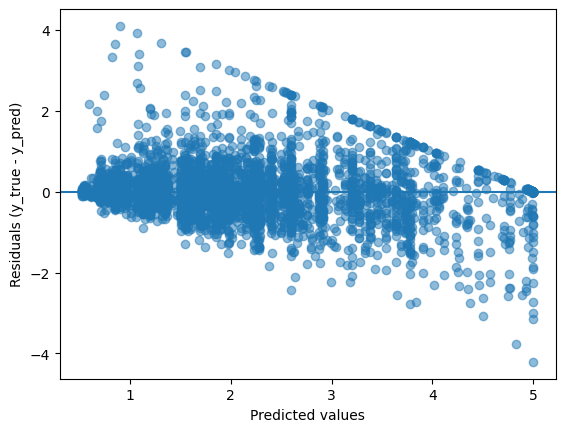

In [22]:
# Computing residual

residuals = ytest - final_y_test_pred

error_df = pd.DataFrame({
    "y_true": ytest,
    "y_pred": final_y_test_pred,
    "residual": residuals
})

import matplotlib.pyplot as plt
plt.figure()
plt.scatter(error_df['y_pred'], error_df['residual'], alpha=0.5)
plt.axhline(0)
plt.xlabel("Predicted values")
plt.ylabel("Residuals (y_true - y_pred)")
plt.show()

Here we can observe that our model makes residuals in smaller magnitudes when it is predicting lower house prices and increasingly higher magnitude error when predicting for expensive houses.


***If the model was consistently wrong on all predictions then it wouldve been biased dominant. My model is inconsistently wrong (correct in some places wrong in others as explained above) which indicates higher variance. Hence an ensemble would help***

In [23]:
# Shifting to a Random Forest Regressor (Ensembles) for potentially better performance

from sklearn.ensemble import RandomForestRegressor

rf_reg = RandomForestRegressor(n_estimators=100)
rf_reg.fit(Xtrain, ytrain)

rf_y_train_pred = rf_reg.predict(Xtrain)
rf_y_val_pred = rf_reg.predict(Xval)

rf_train_mse = mean_squared_error(ytrain, rf_y_train_pred)
rf_val_mse = mean_squared_error(yval, rf_y_val_pred)
round(rf_train_mse, 4), round(rf_val_mse, 4)

(0.0371, 0.2659)

In [25]:
# Evaluating Random Forest Regressor on the test set
rf_test_pred = rf_reg.predict(Xtest)
rf_test_mse = mean_squared_error(ytest, rf_test_pred)
round(rf_test_mse, 4)

0.2784

***Overfitting on train is irrelevant if test error drops.***

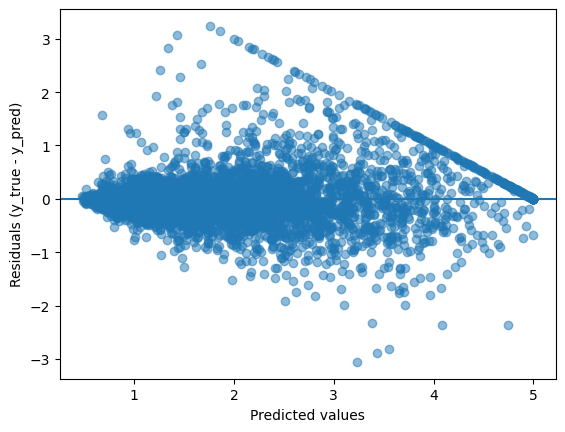

In [26]:
# Error analysis for Random Forest Regressor
rf_residuals = ytest - rf_test_pred
plt.figure()
plt.scatter(rf_test_pred, rf_residuals, alpha=0.5)
plt.axhline(0)
plt.xlabel("Predicted values")
plt.ylabel("Residuals (y_true - y_pred)")
plt.show()

Decision Tree: Worked okay for low prices but was unstable and made large errors for expensive houses.


Random Forest: Smoothed out those errors and generalized much better.


Limitation: House prices are capped at 5.0 in the dataset, so the hard line in the residual plot is a data limitation, not a model issue.